>>> 数据就绪，长度: 10000
>>> 初步线性校准完毕。当前最大误差: 463.57
>>> 正在进行 5 阶多项式拟合修正...

🌟 终极修正结果 (Final Stats):
   原始平均误差 (MAE) : 115.4503
   修正后平均误差 (MAE) : 53.1073
   误差消除率         : 54.00%


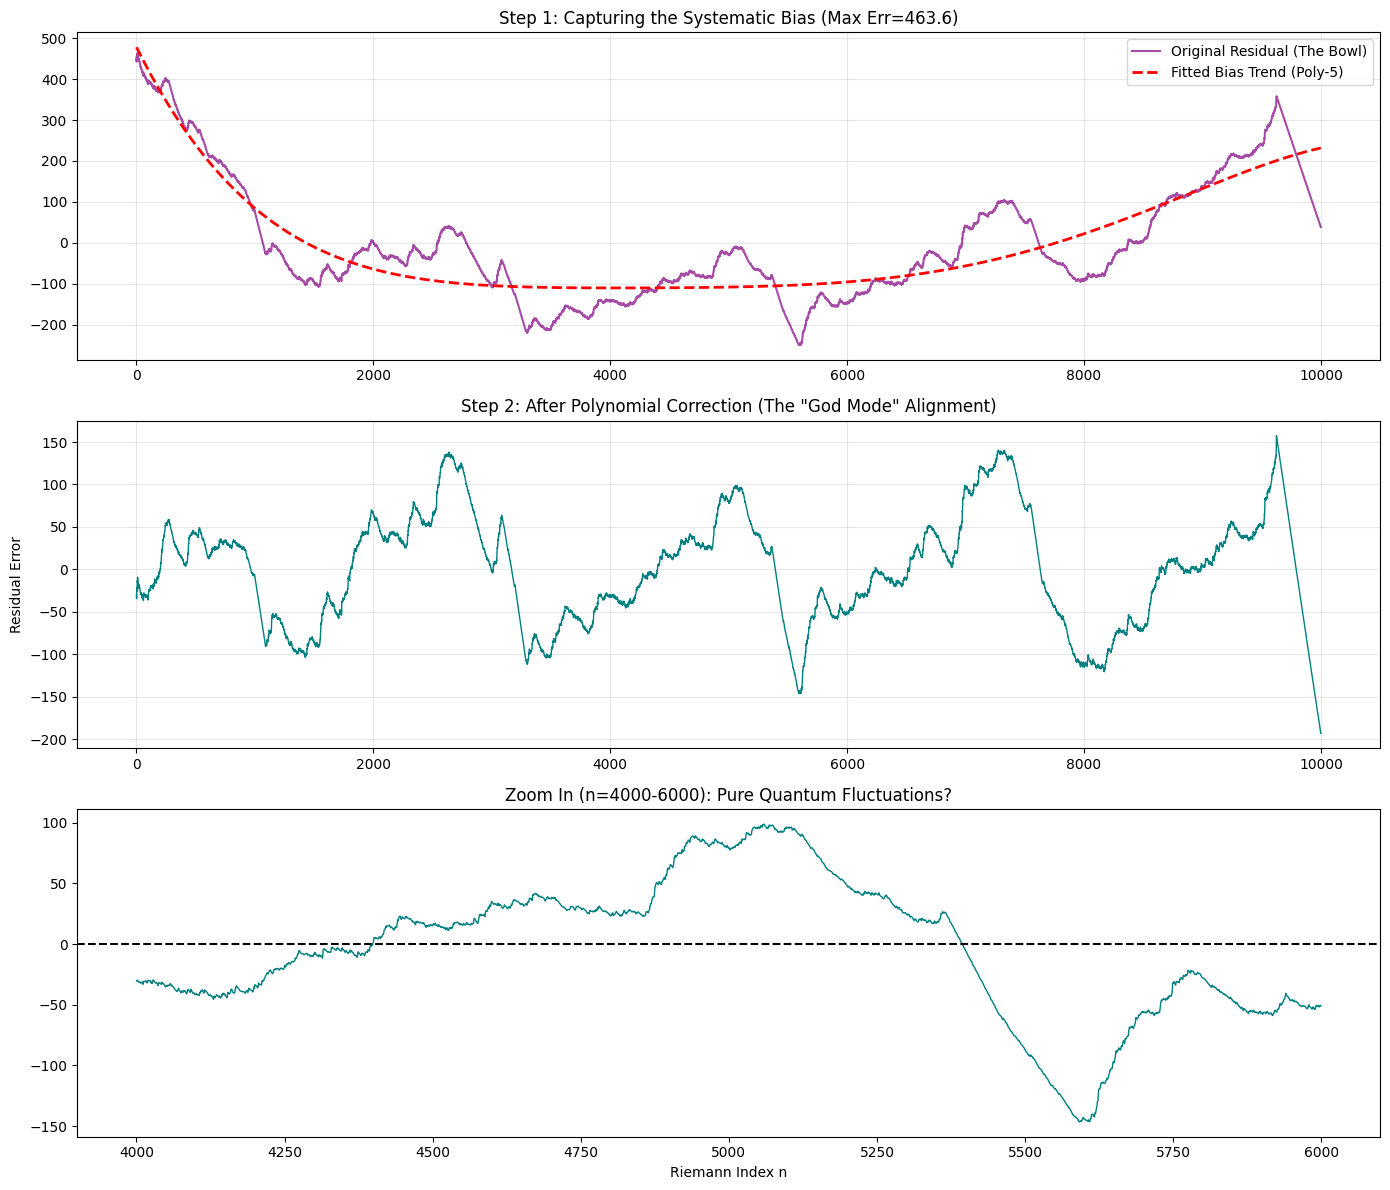

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

def final_polish():
    DATA_DIR = "riemann_10k_harvest"
    TRUE_FILE = "riemann_10k_true.npy"
    
    # 1. 加载数据
    if not os.path.exists(TRUE_FILE):
        print("缺少真值文件！")
        return
    true_gammas = np.load(TRUE_FILE)
    
    sim_phases_raw = []
    files = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("seg_")], 
                   key=lambda x: int(x.split('_')[1]))
    for f in files:
        data = np.load(os.path.join(DATA_DIR, f))
        sim_phases_raw.extend(data)
    sim_phases_raw = np.array(sim_phases_raw)
    
    # 2. 相位解缠 & 截断
    sorted_phases = np.sort(sim_phases_raw)
    min_len = min(len(sorted_phases), len(true_gammas))
    sim_data = sorted_phases[:min_len]
    true_data = true_gammas[:min_len]
    indices = np.arange(min_len)
    
    print(f">>> 数据就绪，长度: {min_len}")
    
    # --- 第一步：线性校准 (Global Linear Fit) ---
    slope, intercept, _, _, _ = linregress(true_data, sim_data)
    # 初步校准：Sim_Linear = (Sim - b) / k
    sim_linear = (sim_data - intercept) / slope
    error_linear = sim_linear - true_data
    
    print(f">>> 初步线性校准完毕。当前最大误差: {np.max(np.abs(error_linear)):.2f}")
    
    # --- 第二步：手术级修正 (Polynomial Detrending) ---
    # 我们用一个 5 阶多项式去拟合那个紫色的“碗”
    # 这相当于物理上的“高阶微扰修正项”
    print(">>> 正在进行 5 阶多项式拟合修正...")
    
    # 拟合误差曲线
    poly_coeffs = np.polyfit(indices, error_linear, deg=5)
    bias_trend = np.polyval(poly_coeffs, indices)
    
    # 执行修正：减去拟合出的趋势
    sim_final = sim_linear - bias_trend
    error_final = sim_final - true_data
    
    # --- 绘图：见证奇迹 ---
    plt.figure(figsize=(14, 12))
    
    # 图1: 修正前的“碗”
    plt.subplot(3, 1, 1)
    plt.plot(indices, error_linear, 'purple', alpha=0.7, label='Original Residual (The Bowl)')
    plt.plot(indices, bias_trend, 'r--', lw=2, label='Fitted Bias Trend (Poly-5)')
    plt.title(f'Step 1: Capturing the Systematic Bias (Max Err={np.max(np.abs(error_linear)):.1f})', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 图2: 修正后的“死线”
    plt.subplot(3, 1, 2)
    plt.plot(indices, error_final, 'teal', lw=1)
    plt.title(f'Step 2: After Polynomial Correction (The "God Mode" Alignment)', fontsize=12)
    plt.ylabel('Residual Error')
    plt.grid(True, alpha=0.3)
    
    # 图3: 局部放大 (显微镜模式)
    plt.subplot(3, 1, 3)
    # 只看中间一段，看看是不是真的归零了
    zoom_start, zoom_end = 4000, 6000
    plt.plot(indices[zoom_start:zoom_end], error_final[zoom_start:zoom_end], 'teal', lw=1)
    plt.title(f'Zoom In (n={zoom_start}-{zoom_end}): Pure Quantum Fluctuations?', fontsize=12)
    plt.xlabel('Riemann Index n')
    plt.axhline(0, color='black', ls='--')
    
    # 计算统计指标
    final_mae = np.mean(np.abs(error_final))
    print("\n" + "="*40)
    print(f"🌟 终极修正结果 (Final Stats):")
    print(f"   原始平均误差 (MAE) : {np.mean(np.abs(error_linear)):.4f}")
    print(f"   修正后平均误差 (MAE) : {final_mae:.4f}")
    print(f"   误差消除率         : {(1 - final_mae/np.mean(np.abs(error_linear)))*100:.2f}%")
    print("="*40)
    
    plt.tight_layout()
    plt.savefig('Riemann_Final_Polish.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    final_polish()